# Importación y revisión de los datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Datos de las visitas

In [3]:
# Carga del dataset y visualización de su estructura
visits = pd.read_csv('datasets/visits_log_us.csv')
visits.info()
print()
print(visits.head())
print(np.unique(visits['Source Id']))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB

    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   

                    Uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4   9969694820

## Datos de las ordenes

In [4]:
# Carga del dataset y visualización de su estructura
orders = pd.read_csv('datasets/orders_log_us.csv')
orders.info()
print()
print(orders.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB

                Buy Ts  Revenue                   Uid
0  2017-06-01 00:10:00    17.00  10329302124590727494
1  2017-06-01 00:25:00     0.55  11627257723692907447
2  2017-06-01 00:27:00     0.37  17903680561304213844
3  2017-06-01 00:29:00     0.55  16109239769442553005
4  2017-06-01 07:58:00     0.37  14200605875248379450


## Datos de los costos

In [5]:
# Carga del dataset y visualización de su estructura
costs = pd.read_csv('datasets/costs_us.csv')
costs.info()
print()
print(costs.head())
print(np.unique(costs['source_id']))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB

   source_id          dt  costs
0          1  2017-06-01  75.20
1          1  2017-06-02  62.25
2          1  2017-06-03  36.53
3          1  2017-06-04  55.00
4          1  2017-06-05  57.08
[ 1  2  3  4  5  9 10]


Posteriormente a la verificación de los dataframe, es evidente que se deben de hacer cambios en cuanto al fomato en los nombres de las columnas, y también en los tipos de datos de las columnas.

# Preprocesamiento de los datos

## Renombramiento de columnas

In [6]:
# Creación de una función para formatear los nombres de las columnas
def columns_format(df):
    formated_columns = []
    for column in df.columns:
        lowercase_column = column.lower()
        no_spaces_column = lowercase_column.strip()
        underscore_column = no_spaces_column.replace(' ','_')
        formated_columns.append(underscore_column)
    return formated_columns

In [7]:
# Formateo de los nombres de las columnas
visits.columns = columns_format(visits)
visits.head()

,device,end_ts,source_id,start_ts,uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


In [8]:
# Formateo de los nombres de las columnas
orders.columns = columns_format(orders)
orders.head()

,buy_ts,revenue,uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


In [9]:
# Formateo de los nombres de las columnas
costs.columns = columns_format(costs)
costs.head()

,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08


## Cambio de tipo de datos

In [10]:
# Conversión de las columnas de tipo obajeto a datetime
visits['end_ts'] = pd.to_datetime(visits['end_ts'])
visits['start_ts'] = pd.to_datetime(visits['start_ts'])
orders['buy_ts'] = pd.to_datetime(orders['buy_ts'])
costs['dt'] = pd.to_datetime(costs['dt'])

# Informes y cálculo de métricas

## Visitas

### ¿Cuántas personas lo usan cada día, semana y mes?

In [11]:
# Agregar columnas de fecha dividido por año, mes, semana y día
visits['session_year']  = visits['start_ts'].dt.isocalendar().year
visits['session_month'] = visits['start_ts'].dt.month
visits['session_week']  = visits['start_ts'].dt.isocalendar().week
visits['session_date'] = visits['start_ts'].dt.date

In [12]:
# Cálcuo del DUA
dau = visits.groupby('session_date').agg({'uid':'nunique'}).reset_index()
dau.columns = ['session_date','daily_active_users']
# Cálculo del DUA total
dau_total = dau['daily_active_users'].mean()
print(f'El DUA total es: {dau_total:.2f} usuarios diarios')

El DUA total es: 907.99 usuarios diarios


In [13]:
#Cálculo del WUA
wau = visits.groupby('session_week').agg({'uid':'nunique'}).reset_index()
wau.columns = ['session_week','weekly_active_users']
# Cálculo del WUA total
wau_total = wau['weekly_active_users'].mean()
print(f'El WAU total es: {wau_total:.2f} usuarios semanales')

El WAU total es: 5825.29 usuarios semanales


In [14]:
# Cálculo del MUA
mua = visits.groupby('session_month').agg({'uid':'nunique'}).reset_index()
mua.columns = ['session_month','monthly_active_users']
# Cálculo del MUA total
mua_total = mua['monthly_active_users'].mean()
print(f'El MUA total es: {mua_total:.2f} usuarios mensuales')

El MUA total es: 23228.42 usuarios mensuales


De acuerdo con los datos obtenidos la se tiene un aproximado de las personas que usan la aplicación de manera, diaria, semanal y mensual. De acuerdo a las métricas el flujo de usuarios por cada periodo refleja bastante actividad dentro de la plataforma de eventos Showz. Aúnque pudiese parecer la única métrica, es importante contrastarla con otros datos y análisis posteriores que serán de ayuda para encontrar debilidades y fortalezas.

### ¿Cuántas sesiones hay por día?

In [15]:
# Cálculo del número de sesiones por usuario
daily_sessions = visits.groupby(['session_year','session_month','session_date']).agg({'uid':['count','nunique']}).reset_index()
daily_sessions.columns = ['session_year','session_month','session_date','n_sessions','n_users']
daily_sessions['sessions_per_user'] = daily_sessions['n_sessions'] / daily_sessions['n_users']
# Cálculo del número promedio de sesiones por usuario y por día en el mes
montly_sessions = daily_sessions.groupby(['session_year','session_month']).agg({'sessions_per_user':'mean','n_sessions':'mean'}).reset_index()
montly_sessions.columns = ['session_year','session_month','avg_sessions_per_user_in_month','avg_sessions_per_day_in_month']

In [16]:
# Promedio de inicios de sesión por usuario
print('Promedio de inicios de sesión por usuario:',montly_sessions['avg_sessions_per_user_in_month'].mean())

Promedio de inicios de sesión por usuario: 1.0822094906655846


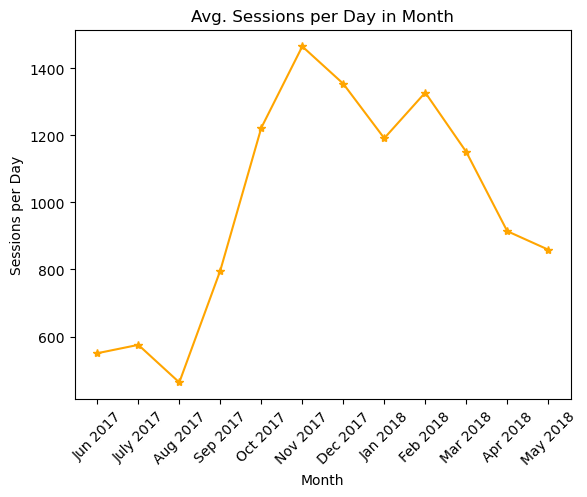

In [17]:
# Análisis de las sesiones promedio por usuario por mes
montly_sessions.sort_values(by=['session_year','session_month'], inplace=True)
montly_sessions.plot(y='avg_sessions_per_day_in_month', kind='line', title='Avg. Sessions per Day in Month',color='orange',rot=45,marker='*')
plt.figsize=(10,10)
plt.legend().remove()
plt.ylabel('Sessions per Day')
plt.xlabel('Month')
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018'])
plt.show()

Con base en los calculos, el promedo obtenido de usuarios que inician sesión es de 1 sesión por usuario, si bien, el hecho de que solo tengan 1 sesión se podría considerar algo negativo, aún tendriamos que contrastar la información contra las ganancias obtenidas de parte de los usuarios y el tiempo que permanecen dentro de las sesiones, puesto que probablemente en una sessión se realicen compras de boletos para diferentes eventos o compras de gran cantidad de boletos(actividades usualmente hecha por revendedores). Por otro lado también se tiene la tabla que nos indica el promedio de las sessiones por día que se realizan por mes, como es fácil de observar, la tendencia de los datos comienza a incrementar en las épocas pegadas a las fechas navideña y final de año, lo cual podría significar que se hacen las compras para regalos navideños o para cualquier otro evento importante para el siguiente año.

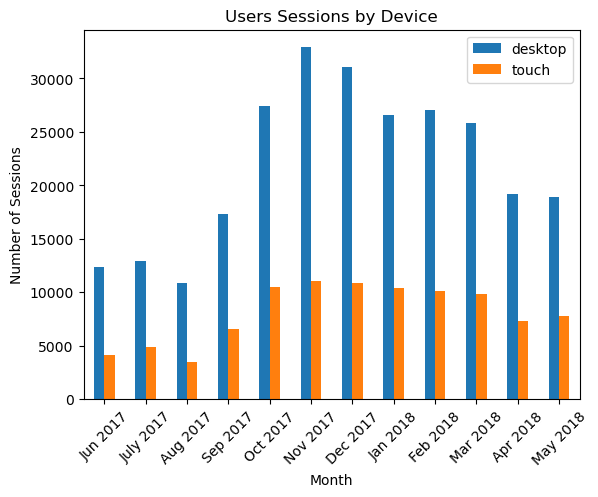

In [18]:
visits_devices = visits.groupby(['session_year','session_month','device']).agg({'uid':'count'}).reset_index()
visits_devices.columns = ['session_year','session_month','device','n_users']    
visits_devices.sort_values(by=['session_year','session_month'], inplace=True)
pivot_devices = visits_devices.pivot(index=['session_year','session_month'], columns='device', values='n_users').reset_index()
pivot_devices.plot(x='session_month', y=['desktop','touch'], kind='bar', title='Users Sessions by Device',rot=45)
plt.figsize=(10,10)
plt.legend()
plt.ylabel('Number of Sessions')
plt.xlabel('Month')
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018'])
plt.show()

De acuerdo con la gráfica de los usuarios por dispositivo se puede ver una clara dominancia por parte de ususarios que utilizan dipositivos denominados desktop, que muy probablemente son computadoras, sobre usuarios que utilizan dispositivos touch que pueden ser dispositvos móviles. Lo anterior puede implicar dos cosas, la plataforam de Showz únicamente tiene un portar web por el cual los usuarios pueden acceder independientemente del dispositivo, o por otra parte, si la pataforma cuenta con una aplicación móvil, quiere decir que no es tan popular o intuitiva como para que los usuarios prefieran acceder mediante dispositivos móviles.

### ¿Cuál es la duración de cada sesión?

In [19]:
# Cálclo de la duración promedio de las sesiones
visits['session_duration'] = (visits['end_ts'] - visits['start_ts']).dt.total_seconds()
avg_session_duration = visits['session_duration'].mean()  
print(f'La duración promedio de las sesiones es: {avg_session_duration:.2f} segundos')

La duración promedio de las sesiones es: 643.03 segundos


Según el promedio de la duración de las sesiones se tiene que duran un aproximado de 10 a 11 minutos por sesión, lo cual podría indicar que probablemente se realicen más de una operación por sesion, si embargo, también hay que considerar cuestiones como errores en la plataforma, un diseño poco intuitivo o el uso del servicio para compras muy grandes.

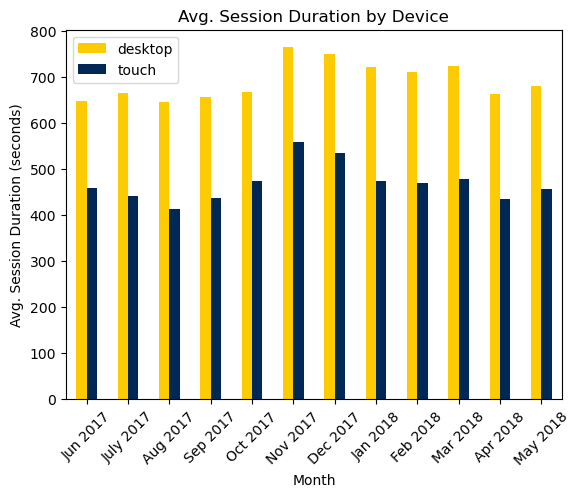

In [20]:
devices_duraton = visits.groupby(['session_year','session_month','device']).agg({'session_duration':'mean'}).reset_index()
devices_duraton.columns = ['session_year','session_month','device','avg_session_duration']
pivot_devices_duration = devices_duraton.pivot(index=['session_year','session_month'], columns='device', values='avg_session_duration').reset_index()
pivot_devices_duration.plot(x='session_month', y=['desktop','touch'], kind='bar', title='Avg. Session Duration by Device', color=['#FCCB02','#002856'],rot=45)
plt.legend()
plt.ylabel('Avg. Session Duration (seconds)')
plt.xlabel('Month')
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018'])
plt.show()

En perspectiva, podemos ver que la duración de las sesiones por dispositivo sigue siendo predominante por los dispositivos desktop, sobre los dispositivos touch, sin embargo la diferencia en la duración de las sesiones no es tan grande, dicho detalle puede significar que a pesar de que los usuarios prefieren entrar mediante la página web en dispositivos considerados desktop, tambien hay una cierta comodidad en el uso de dispositivos touch. Si bien lo dicho anteriormente es una mera hipótesis, habría que comprar otros datos para saber cual es la posible causa de que los dispositivos touch sean los menos frecuentes para acceder a la plataforma de compras de tickets.

### ¿Con qué frecuencia los usuarios regresan?

In [21]:
# Clculo del factor de adherencia por semana
sticky_wau = (dau_total / wau_total) * 100
print(f'Frecuencia con la que regresan los usuarios a la semana es de: {sticky_wau:.2f}%')
# Clculo del factor de adherencia por mes
sticky_mau = (dau_total / mua_total) * 100
print(f'Frecuencia con la que regresan los usuarios al mes es de: {sticky_mau:.2f}%')

Frecuencia con la que regresan los usuarios a la semana es de: 15.59%
Frecuencia con la que regresan los usuarios al mes es de: 3.91%


El factor de adherencia es bastante bajo al la semana y al mes, en terminos más practicos se puede decir que a la semana solamente al rededor de 15 usuarios de 100 regresan a utilizar la plataforma, y mensualmente solo entre 3 y 4 usuarios de 100 regresan. Es una cantidad absurdamente baja, teniendo en cuenta que las metricas del DAU, WAU y MAU son grandes, esto quiere decir que se tienen muchos usuarios nuevos a lo largo del año, pero solo una pequeña cantidad de ellos vuelve a hacer uso del servicio. Los usuarios son muy casuales y solo se presentan por temporadas.

## Ventas

### ¿Cuándo empieza la gente a comprar?

In [22]:
# Agrupación por mes de la primera visita y primer pedido
first_visit = visits.groupby('uid')['start_ts'].min().reset_index()
first_visit.columns = ['uid','first_visit']
first_order = orders.groupby('uid')['buy_ts'].min().reset_index()
first_order.columns = ['uid','first_order']

# Cración del dataframe user_journey y cálculo de los días hasta la conversión y el mes y año del primer pedido
user_journey = first_visit.merge(first_order, on='uid', how='outer')
user_journey['days_to_conversion'] = (user_journey['first_order'] - user_journey['first_visit']).dt.days
user_journey['first_order_month'] = user_journey['first_order'].dt.month
user_journey['first_order_year'] = user_journey['first_order'].dt.year

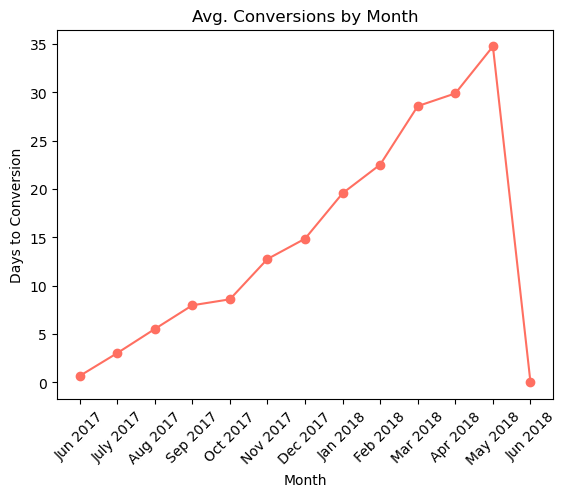

In [23]:
# Agrupación por mes y año de la primera visita y cálculo del promedio de días hasta la conversión
conversion_by_month = user_journey.groupby(['first_order_year','first_order_month']).agg({'days_to_conversion':'mean'}).reset_index()
conversion_by_month.columns = ['first_order_year','first_order_month','avg_days_to_conversion'] 
conversion_by_month.sort_values(by=['first_order_year','first_order_month'], inplace=True)

# Graficación de las conversiones por mes a lo largo del año
conversion_by_month.plot(y='avg_days_to_conversion', kind='line', title='Avg. Conversions by Month',rot=45, marker='o', color='#FF6F61')
plt.legend().remove()
plt.ylabel('Days to Conversion')
plt.xlabel('Month')
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018','Jun 2018'])
plt.show()

La gráfica muestra un comportamiento alarmante de parte de los usuarios, puesto que conforme pasa el tiempo tardan más en decidirse en ser clientes de la plataforma de Showz, este comportamiento es sumamente negativo, puesto que genera diferentes factores que afectan en las inversiones e ingresos de la plataforma. Conforme el tiempo de conversión aumenta, hay una alta posibilidad de que los usuarios vayan con la competencia, el costo de adquisición por cliente comienza a aumentar y aunado a los bajos factores de adherencia las ganancias son demasiado bajas.

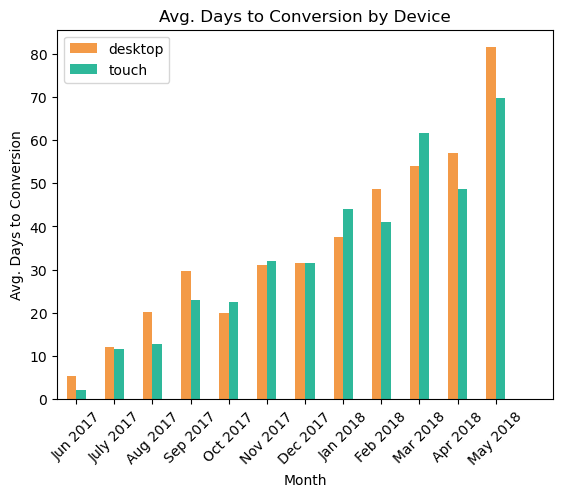

In [24]:
uid_devices = visits[['uid','device']]
uid_devices = user_journey.merge(uid_devices, on='uid', how='left')
conversion_by_device = uid_devices.groupby(['first_order_year','first_order_month','device']).agg({'days_to_conversion':'mean'}).reset_index()
pivot_devices_duration = conversion_by_device.pivot_table(index=['first_order_year','first_order_month'], columns='device', values='days_to_conversion', aggfunc='sum').reset_index().fillna(0)
pivot_devices_duration.plot(x='first_order_month', y=['desktop','touch'], kind='bar', title='Avg. Days to Conversion by Device', color=["#F39A47","#2EB89A"],rot=45)
plt.legend()
plt.ylabel('Avg. Days to Conversion')
plt.xlabel('Month')
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018'])
plt.show()

Como se puede observar en la gráfica, la mayor cantidad de días de conversión vienen de parte de los dispositivos desktop y no por los dispositivos tocuh como se pensaría. Esto deja entrever ciertas posibilidades, la interfaz de los usuarios de dispositivos desktipo es poco intuitiva o poco clara al momento de que el usuario debe de hacer las compras en compración con la versión de dispositivos touch, probablemente es mucho más sencillo comprar en la comodidad de un dispositivo touch en cualquier momento, lugar y hora, y por último, el marketing para dipositivos touch es mucho más eficiente que para dispositivos desktop. Muchas de estas incognitas podran ser respondidas a lo largo del proyecto.

### ¿Cuántos pedidos hacen durante un período de tiempo dado?

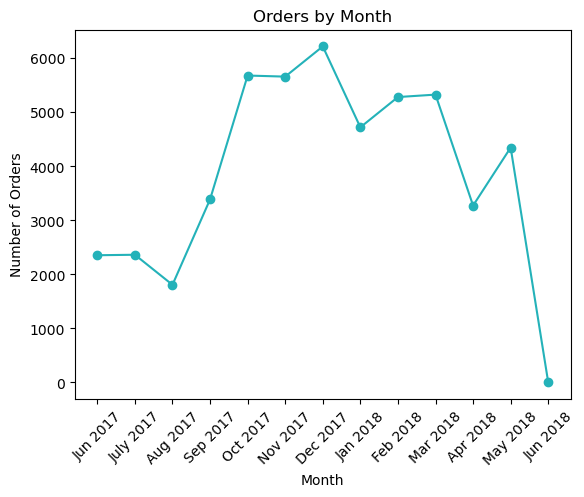

In [25]:
# Agrupación por mes y año del pedido y conteo del número de pedidos
orders['order_month'] = orders['buy_ts'].dt.month
orders['order_year'] = orders['buy_ts'].dt.year
orders_number = orders.groupby(['order_year','order_month']).agg({'uid':'count'}).reset_index()
orders_number.columns = ['order_year','order_month','n_orders']
orders_number.sort_values(by=['order_year','order_month'], inplace=True)

# Graficación del número de pedidos por mes a lo largo del año
orders_number.plot(y='n_orders', kind='line', title='Orders by Month',rot=45,color="#24B2B9", marker='o')
plt.legend().remove()
plt.ylabel('Number of Orders')
plt.xlabel('Month')
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018','Jun 2018'])
plt.show()

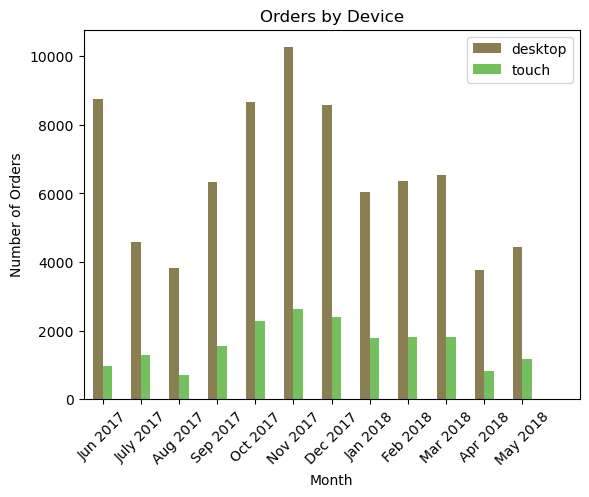

In [26]:
orders_by_device = uid_devices.groupby(['first_order_year','first_order_month','device']).agg({'uid':'count'}).reset_index()
orders_by_device.columns = ['first_order_year','first_order_month','device','n_orders']
pivot_orders_by_device = orders_by_device.pivot_table(index=['first_order_year','first_order_month'], columns='device', values='n_orders', aggfunc='sum').reset_index().fillna(0)
pivot_orders_by_device.plot(x='first_order_month', y=['desktop','touch'], kind='bar', title='Orders by Device', color=["#8A7F52","#74C05E"],rot=45) 
plt.legend()
plt.ylabel('Number of Orders')
plt.xlabel('Month')
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018'])
plt.show()

Se puede observar que la cantidad de pedidos comienza a repuntar en el més de agosto de 2017 y toca su punto más bajo en abril 2018, esto muestra que existe una tendencia por parte de los usuarios que comienza en agosto, probablemente porque haya más ofertas o los eventos importantes y populares suelan empezar su venta desde esas fechas.

Si bien la tendencia sigue predominando en los dispositivos desktop, si hay algo que puntualizar a cerca de la gráfica mostrada. Anteriormente en la tabla de las conversiones se pudo ver que en algunos meses los dispositivos touch superaron en número de conversión a los desktop, lo anterior plantea una pregunta importante ¿es a caso que los dispositivos touch tienen un potencial que no ha sido explotado para la atracción, venta y retención de los usuarios?, si nos enfocamos puntualmente en el mes de marzo de ambas gráficas podremos ver que a pesar de tener muy pocas ordenes hechas mediantes dispositivos touch, fue el mes en el que mayor cantidad de usuarios se volvieron clientes, esto no es para nada insignificante puesto que muestra un potencial poco aprovechado.

### ¿Cuál es el tamaño promedio de compra?

In [27]:
# Agrupación por mes y año del pedido y cálculo del ingreso promedio por pedido
mean_purchase = orders.groupby(['order_year','order_month']).agg({'revenue':'mean'}).reset_index()
mean_purchase.columns = ['order_year','order_month','mean_revenue']
mean_purchase.sort_values(by=['order_year','order_month'], inplace=True)

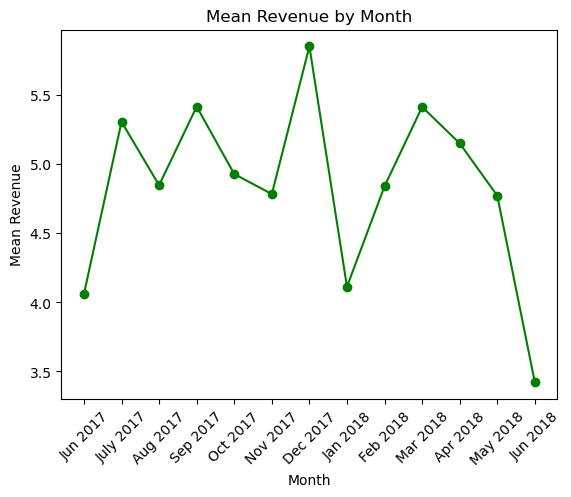

In [28]:
# Graficación del ingreso promedio por pedido a lo largo del año
mean_purchase.plot(y='mean_revenue', kind='line', title='Mean Revenue by Month',color='green',rot=45, marker='o')
plt.legend().remove()
plt.ylabel('Mean Revenue')
plt.xlabel('Month')
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018','Jun 2018'])
plt.show()

La gráfica anterior muestra el promedio de ganancias a lo largo del año por cada mes. Algo importante a puntualizar es que aquí el repunte de ingresos no comienza tan fuerte en el mes de agosto a pesar de que en la tabla anterior es dónde comienzan a hacerce más ordenes, para este caso, el punto donde hay mas ingresos en promedio es el més de diciembre, que en un anterior análisis se vió como el punto que coincide con la temporada navideña. A partir del punto más alto de ingresos se puede ver que en la temporada de inicio de año estos caen abruptamente, esto es comprensible, pues en su mayoría las personas que hicieron compras navideñas y de fin de año no suelen gastar a inicios del siguiente año de la misma manera.

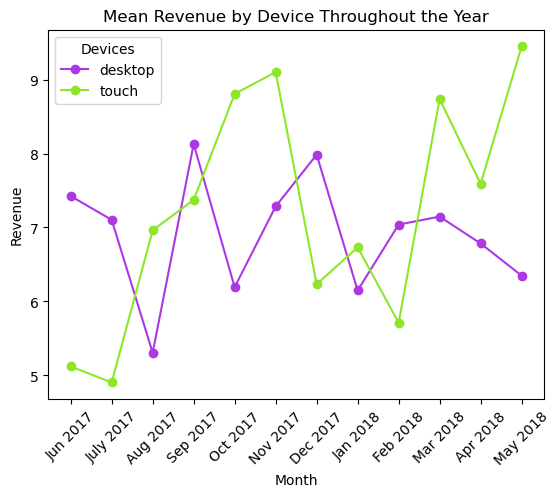

In [29]:
# Agrupación de datos por mes y año y fuente de markeintg
customers = visits.groupby('source_id').agg({'uid':'nunique'}).reset_index().sort_values(by='uid', ascending=False)
customers.columns = ['source_id','n_customers']
devices_purchase = visits[['uid','source_id','session_year','session_month','device']].merge(orders[['uid','revenue']], on='uid')
revenue_by_purchase = devices_purchase.groupby(['session_year','session_month','source_id','device']).agg({'revenue':'mean'}).reset_index()
revenue_by_purchase.sort_values(by=['session_year','session_month'], inplace=True)
revenue_by_purchase = revenue_by_purchase.merge(customers[['source_id','n_customers']], on='source_id')

# Graficación del LTV por fuentes de marketing
revenue = revenue_by_purchase.pivot_table(index=['session_year','session_month'], columns='device', values='revenue',aggfunc='mean').reset_index().fillna(0)
revenue.iloc[:,2:].plot(kind='line', title='Mean Revenue by Device Throughout the Year', color=["#AC38E2","#8EE629"], rot=45, marker='o')
plt.legend(title='Devices')
plt.ylabel('Revenue')
plt.xlabel('Month')
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018'])
plt.show()

De acuerdo con la tabla se puede ver que el promedio de ingresos por dipositivo es mayor para los dispositivos touch que para los disposisitovs desktop. Si bien el la diferencia es mínma, existe aunque también hay que considerar otros factores que afectan las demás métricas que se verán posteriormente. Lo que si cabe puntualizar es la gran fluctuación que existe para las ganancias de ambos dispositivos, se nota que son muy inestables y tienden a subir y bajar en el tiempo, no se mantienen, en algunos puntos en concreto si existen tendencias a la alta, pero también las hay a la baja. Tal comportamiento refleja una gran inestabilidad de las ganancias, algo no tan bueno si consideramos que es necesario obtener retorno de la inversión para que el negocio siga funcionando y sea redituable.  

### ¿Cuánto dinero traen? (LTV)

In [30]:
# Agrupación por mes y año del primer pedido y conteo del número de usuarios que realizaron su primer pedido en ese mes
orders['date_order'] = orders['buy_ts'].dt.to_period('M')
mainly_orders = orders.groupby('uid').agg({'date_order':'min'}).reset_index()
mainly_orders.columns = ['uid','first_order_month']
cohort_sizes = mainly_orders.groupby('first_order_month').agg({'uid':'nunique'}).reset_index()
cohort_sizes.columns = ['first_order_month','n_users']

In [31]:
# Combinación de los dataframes orders y mainly_orders para obtener el mes del primer pedido de cada usuario
orders_ltv = pd.merge(orders, mainly_orders, on='uid')
# Cálculo de los ingresos totales por mes de la primera compra y del mes del pedido
cohort = orders_ltv.groupby(['first_order_month','date_order']).agg({'revenue':'sum'}).reset_index()
report = pd.merge(cohort_sizes, cohort, on='first_order_month')

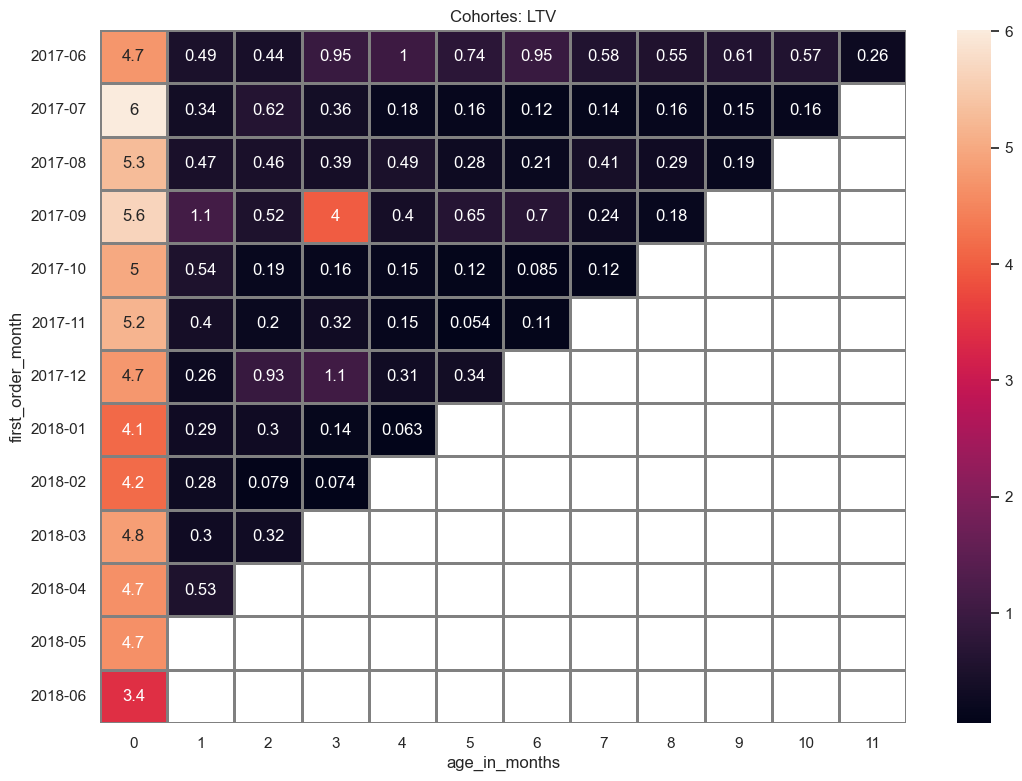

In [32]:
# Se propone un margen de ganancia del 100%
margin_rate = 1
report['gross_profit'] = report['revenue'] * margin_rate
report['age_in_months'] = (report['date_order'] - report['first_order_month']).apply(lambda x: x.n)
report['ltv'] = report['gross_profit'] / report['n_users']
ltv_cohort = report.pivot_table(index='first_order_month', columns='age_in_months', values='ltv', aggfunc='mean')
ltv_cohort.fillna('')

sns.set_theme(style='white')
plt.figure(figsize=(13, 9))
plt.title('Cohortes: LTV')
plt.ylabel('First Order Month')
plt.xlabel('Age in Months')
sns.heatmap(
    ltv_cohort, annot=True, linewidths=1, linecolor='gray'
)
plt.show()

Acorde con el mapa de calor de la cohorte de LTV, es evidente que las ganancias promedio que son aportadas por cliente es demasiado baja, en ningún momento los ingresos vuelven a ser iguales o incluso superiores que al comienzo del ciclo, es to es una mala señal puesto que los ingresos puede que no seansuficientes para poder solventar los demás gastos, o puede que los ingresos sean suficientes como para solamente solventarlo pero no tener una ganancia significativa. En cualquiera de los dos casos no sería un negocio rentable.

## Marketing

### ¿Cuánto dinero se gastó?

In [33]:
# Creación de la tabla de costos mensuales totales y su suma anual
costs['session_month'] = costs['dt'].dt.month
costs['session_year'] = costs['dt'].dt.year
monthly_total_costs = costs.groupby(['session_year','session_month']).agg({'costs':'sum'}).reset_index()
monthly_total_costs.columns = ['session_year','session_month','total_cost_per_month']
print('Costo total en el año es: $', monthly_total_costs['total_cost_per_month'].sum())

Costo total en el año es: $ 329131.62


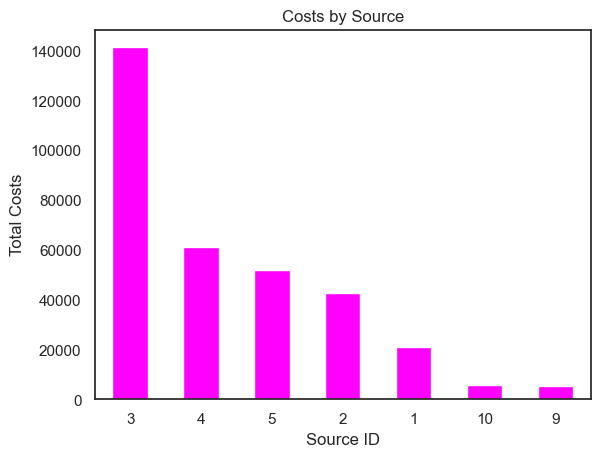

In [34]:
# Creación de gráfico de costos por fuente
sources_costs = costs.groupby('source_id').agg({'costs':'sum'}).reset_index().sort_values(by='costs', ascending=False)
sources_costs.plot(x='source_id', y='costs', kind='bar', title='Costs by Source',color='magenta',rot=0)
plt.legend().remove()
plt.ylabel('Total Costs')
plt.xlabel('Source ID')
plt.show()

En consonancia con los resultados obtenidos, se puede ver que la inversión a la fuente de marketing número 3 es la mayor de todas, esto se puede deber a que probablemente es una fuente anuncios bastante popular y de la cual se obtienen muchos usuarios que en su mayoría se convierten en clientes.

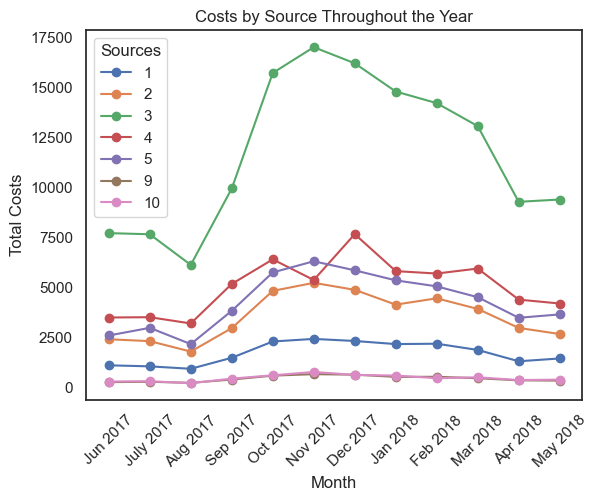

In [35]:
# Creación de gráfico de costos por fuente a lo largo del año
sources_costs_by_time = costs.groupby(['session_year','session_month','source_id']).agg({'costs':'sum'}).reset_index()
sources_costs_by_time.sort_values(by=['session_year','session_month'], inplace=True)

# Graficación de los costos de cada fuente de marketing a lo largo del año
sources = sources_costs_by_time.pivot(index=['session_year','session_month',], columns='source_id', values='costs').reset_index()
sources.iloc[:,2:].plot(kind='line', title='Costs by Source Throughout the Year', rot=45, marker='o')
plt.legend(title='Sources')
plt.ylabel('Total Costs')
plt.xlabel('Month')
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018'])
plt.show()

Conforme a lo mostrado en la sección anterior, se puede observar que los costos varían dependiendo de la fuente de marketing, para este caso en partícular se puede ver que el canal de marketing correspondiente al ID 3 es el que mayor inversión tiene a lo largo del tiempo, además se puede ver que las tendencias comienzan a tener un repunte en el mes de agosto, un comportamiento que ya se había observado en análisis anteriores.


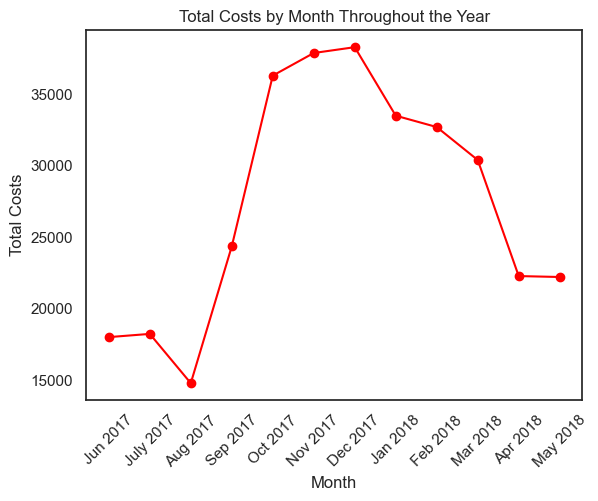

In [36]:
# Creación de gráfico de costos mensuales totales a lo largo del año
monthly_total_costs.sort_values(by=['session_year','session_month'], inplace=True)
monthly_total_costs.plot(y='total_cost_per_month', kind='line', title='Total Costs by Month Throughout the Year',color='red', rot=45, marker='o')
plt.legend().remove()
plt.ylabel('Total Costs')
plt.xlabel('Month')
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018'])
plt.show()

Al igual que la anterior gráfica es muy notorio que el repunte comienza en el mes de agosto, esto quiere decir que tanto las ingresos y las inversiones dependen de temporadas. Si bien esto es bastante bueno, aún hay que verificar como esos gastos se compensan con las ganancias obtenidas en el año, de nada sirve gastar grandes sumas de dinero si el retorno de esa inversión nunca va a llegar.

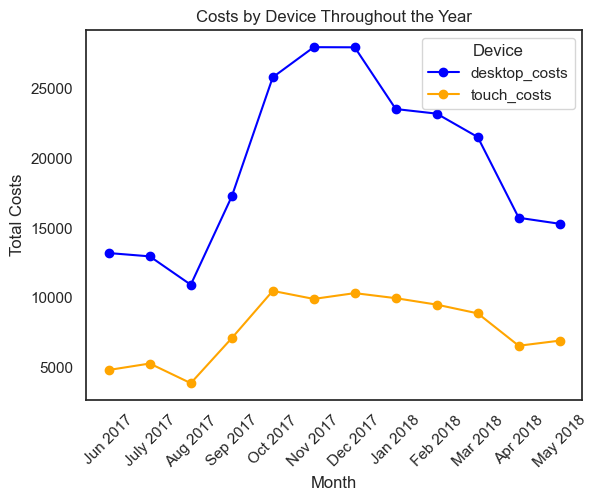

     source_id   device  session_year  session_month  n_devices
0            1  desktop          2017              6        705
1            1  desktop          2017              7        747
2            1  desktop          2017              8        588
3            1  desktop          2017              9        975
4            1  desktop          2017             10       1524
..         ...      ...           ...            ...        ...
187         10    touch          2018              1        295
188         10    touch          2018              2        309
189         10    touch          2018              3        396
190         10    touch          2018              4        164
191         10    touch          2018              5        267

[192 rows x 5 columns]


In [37]:
# Agrupación por mes y año del costo por dispositivo
devices = visits[['device','source_id','uid','session_month','session_year']]
devices = devices.groupby(['source_id','device','session_year','session_month']).agg({'uid':'nunique'}).reset_index()
devices.columns = ['source_id','device','session_year','session_month','n_devices']
pivot_dev = devices.pivot_table(index=['session_year','session_month'], columns='device', values='n_devices', aggfunc='sum').reset_index()
costs_by_devices = pivot_dev.merge(monthly_total_costs, on=['session_year','session_month'], how='inner')
costs_by_devices['desktop_costs'] = costs_by_devices['desktop'] * costs_by_devices['total_cost_per_month'] / (costs_by_devices['desktop'] + costs_by_devices['touch'])
costs_by_devices['touch_costs'] = costs_by_devices['touch'] * costs_by_devices['total_cost_per_month'] / (costs_by_devices['desktop'] + costs_by_devices['touch'])
# Graficación de los costos por dispositivo a lo largo del año
costs_by_devices.plot(y=['desktop_costs','touch_costs'], kind='line', title='Costs by Device Throughout the Year',color=['blue','orange'], rot=45, marker='o')
plt.legend(title='Device')
plt.ylabel('Total Costs')
plt.xlabel('Month')
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018'])
plt.show()
print(devices)

Como se puede observar los dispositivos en los que recae más el costo del marketing son los desktop, pues es la mayor cantidad de ellos los que los usuarios usa para entrar en los canales de marketing. Es interesante ver como a pesar de que el costo es total y no compartido, se puede calcular que porcentaje de ese costo se aprovecha por cada una de sus fuentes. Para este caso en particular, cada uno de los dispositivos aprovecha el costo que se invierte en el marketing, podríamos decir que quien mayormente lo aprovecha es la parte de los usuarios que entran a la plataforma utilizando el dispositivo más recurrente, en este caso los dispositivos desktop, sin embargo, el que se invierta mayor presupuesto en marketing no necesariamente se va a traducir en mejores y mayores ganancias. En los siguientes puntos del proyecto se verá si efectivamente las inversiones hechas son redituables y sobre todo estan enfocadas en sectores que lo necesitan.

### ¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes? 

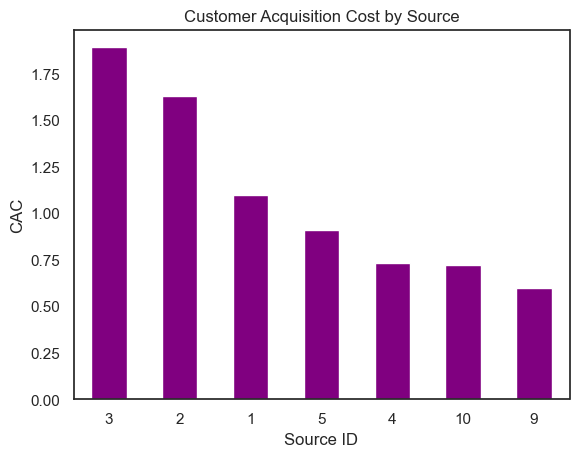

In [38]:
# Agrupación por fuente del primer pedido y conteo del número de usuarios que realizaron su primer pedido por fuente
costs_by_source = costs.groupby('source_id').agg({'costs':'sum'}).reset_index().sort_values(by='costs', ascending=False)
cac_by_source = costs_by_source.merge(customers, on='source_id')
cac_by_source['cac_sources'] = cac_by_source['costs'] / cac_by_source['n_customers']
cac_by_source.sort_values('cac_sources', ascending=False, inplace=True)

# Graficación del CAC por fuente
cac_by_source.plot(x='source_id',y='cac_sources', kind='bar', title='Customer Acquisition Cost by Source',color='purple', rot=0)
plt.legend().remove()
plt.ylabel('CAC')
plt.xlabel('Source ID')
plt.show()

Como se puede observar, el costo de adquisición de los clientes visto por la perspectiva de las fuentes de marketing es liderado por la fuente número 3, en la cual quiere decir que a la empresa le costó un aproximado de $1.8 dolares atraer a un cliente utilizando esa fuente en específico. Aunque pareciese un valor menor o poco significativo, se debe de comparar con la cantidad de ingresos que esa fuente nos va a proporcionar al captar más usuarios, lo anterior se va a analizar en secciones posteriores al proyecto.

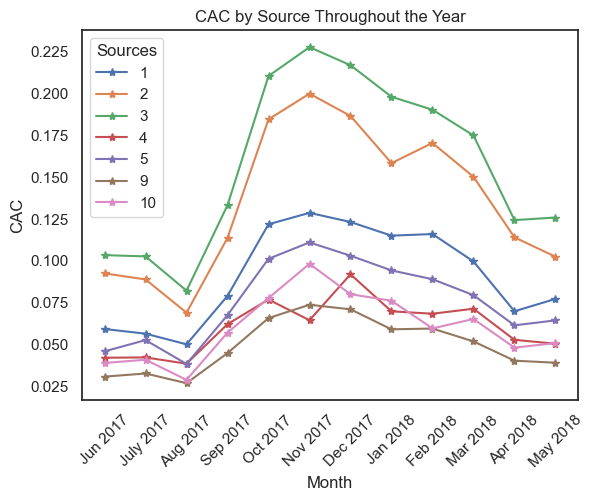

In [39]:
# Creación de gráfico de costos por fuente a lo largo del año
costs_by_source_in_time = costs.groupby(['session_year','session_month','source_id']).agg({'costs':'sum'}).reset_index()
costs_by_source_in_time.sort_values(by=['session_year','session_month'], inplace=True)
costs_by_source_in_time = costs_by_source_in_time.merge(customers[['source_id','n_customers']], on='source_id')
costs_by_source_in_time['cac_by_source'] = costs_by_source_in_time['costs'] / costs_by_source_in_time['n_customers']

# Graficación de el CAC por fuente de marketing a travez del tiempo
costs_cac = costs_by_source_in_time.pivot(index=['session_year','session_month'], columns='source_id', values ='cac_by_source').reset_index()
costs_cac.iloc[:,2:].plot(kind='line', title='CAC by Source Throughout the Year',rot=45, marker='*')
plt.legend(title='Sources')
plt.ylabel('CAC')
plt.xlabel('Month')
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018'])
plt.show()

Como anteriormente ya se veía la fuente 3 es la que mayor inversión se le aplica para la adquisición de un cliente. Por otra parte es importante resaltar que siguen tomando esa tendencia a la alta que comienza en el mes de agosto. La información mas adelante se complementará con las gráficas de los resultados del LTV y el ROMI principalmente, puesto que por si sola la métrica del CAC solamente nos dice la cantidad de dinero que se invirtió para conseguir un cliente, por lo que sin otro punto de comparación no se podría dar una conclusión más allá de lo que ya se comentó.

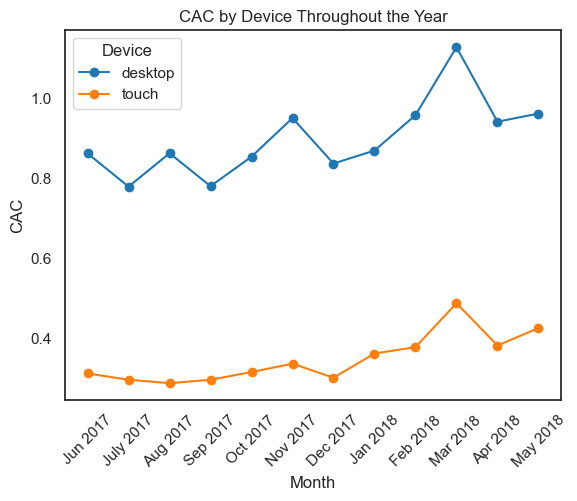

In [40]:
# Agrupación por mes y año del costo por dispositivo
cac_by_devices = costs.groupby(['session_year','session_month','source_id']).agg({'costs':'sum'}).reset_index()
cac_by_devices = cac_by_devices.merge(devices, on=['session_year','session_month','source_id'])
cac_by_devices['cac_device'] = cac_by_devices['n_devices'] / cac_by_devices['costs']
# Graficación del CAC por dispositivo a lo largo del año
pivot_cac_by_devices = cac_by_devices.pivot_table(index=['session_year','session_month'], columns='device', values ='cac_device').reset_index()
pivot_cac_by_devices.iloc[:,2:].plot(y=['desktop','touch'], kind='line', title='CAC by Device Throughout the Year',color=['#1F77B4','#FF7F0E'], rot=45, marker='o')
plt.legend(title='Device')
plt.ylabel('CAC')
plt.xlabel('Month')
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018'])
plt.show()

Como se ha venido mostrando, los dispositivos a los cuales se les tiene mayor consideración son los denominados desktop. De la misma manera que hicimos el análisis anterior, es obvio que es la categoría de dispositivos a la cuál se le ha destinado más recursos y también la más popular, sin embargo, no quiere decir que sea la más rentable. Al principio del proyecto pudimos observar que hay varios indicios en dónde esta categoría no se desempeña completamente bien, sin embargo, hasta no tener la información complementaria no podremos dar un veredícto final.

### ¿Cuán rentables eran las inversiones?

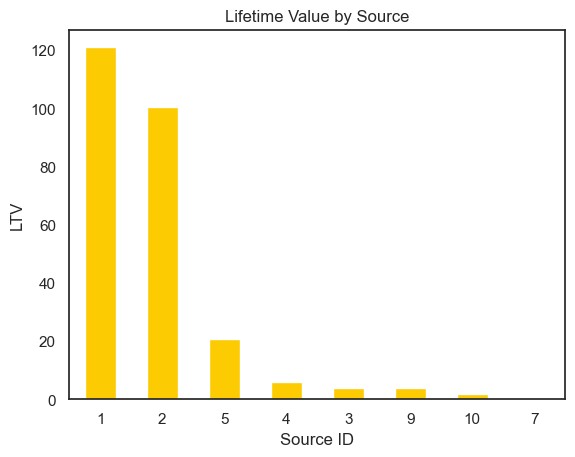

In [41]:
# Cálculo del LTV por fuente
source_id_ltv = visits[['uid','source_id','session_year','session_month']].merge(orders[['uid','revenue']], on='uid')
revenue_by_source = source_id_ltv.groupby('source_id').agg({'revenue':'sum'}).reset_index()
revenue_by_source = revenue_by_source.merge(customers[['source_id','n_customers']], on='source_id')
revenue_by_source['ltv_sources'] = revenue_by_source['revenue'] / revenue_by_source['n_customers']
revenue_by_source.sort_values(by='ltv_sources', ascending=False, inplace=True)
revenue_by_source.plot(x='source_id', y='ltv_sources', kind='bar', title='Lifetime Value by Source', color='#FCCB02' ,rot=0)
plt.legend().remove()
plt.ylabel('LTV')
plt.xlabel('Source ID')
plt.show()

Acorde con la tabla la fuente de marketing 1 es por dónde mas ganancias se reciben de parte de los clientes. Muy probablemente sea una muy pooular relacionada con redes sociales o alguna otra manera de convencer de manera fácil a los clientes para que realicen compras de tickets.

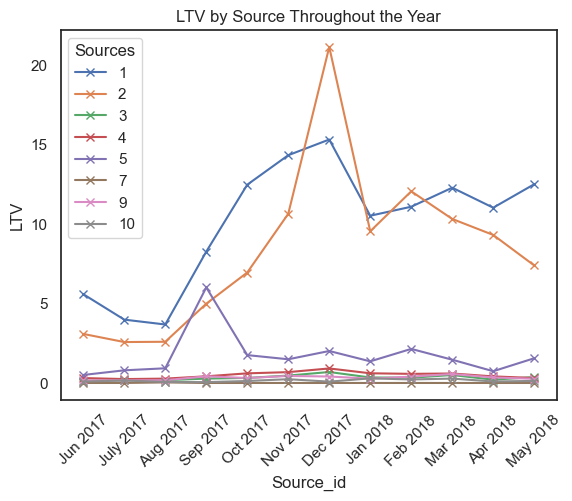

In [42]:
# Agrupación de datos por mes y año y fuente de markeintg
source_id_ltv = visits[['uid','source_id','session_year','session_month']].merge(orders[['uid','revenue']], on='uid')
revenue_by_time = source_id_ltv.groupby(['session_year','session_month','source_id']).agg({'revenue':'sum'}).reset_index()
revenue_by_time.sort_values(by=['session_year','session_month'], inplace=True)
revenue_by_time = revenue_by_time.merge(customers[['source_id','n_customers']], on='source_id')
revenue_by_time['ltv_by_source'] = (revenue_by_time['revenue'] / revenue_by_time['n_customers'])
# Graficación del LTV por fuentes de marketing
costs_ltv = revenue_by_time.pivot(index=['session_year','session_month'], columns='source_id', values='ltv_by_source').reset_index().fillna(0)
costs_ltv.iloc[:,2:].plot(kind='line', title='LTV by Source Throughout the Year', rot=45, marker='x')
plt.legend(title='Sources')
plt.ylabel('LTV')
plt.xlabel('Source_id')
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018'])
plt.show()

De acuerdo con la perspectiva de la gráfica se puede seguir viendo una tendencia en el mes de agosto, además que la fuente 1 es la que mayores ganancias obtiene, si bien pareciese que la fuente 2 es la que las tiene, si se analísa a detalle se puede ver que durante gran parte del año las ganancias de la fuente 2 se encuentran debajo de las ganancias de la fuente 1, solo en algunos momentos muy específicos la logra superar como en diciembre del 2017 y febrero del 2018, sin embargo, no quiere decir que sea superior.

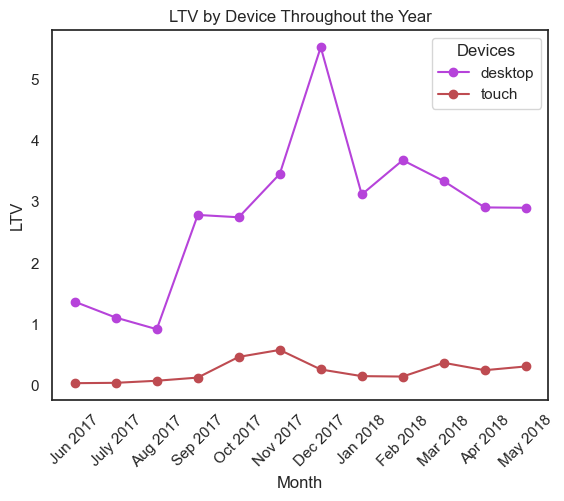

In [43]:
# Agrupación de datos por mes y año y fuente de markeintg
device_ltv = visits[['uid','source_id','session_year','session_month','device']].merge(orders[['uid','revenue']], on='uid')
revenue_by_device = device_ltv.groupby(['session_year','session_month','source_id','device']).agg({'revenue':'sum'}).reset_index()
revenue_by_device.sort_values(by=['session_year','session_month'], inplace=True)
revenue_by_device = revenue_by_device.merge(customers[['source_id','n_customers']], on='source_id')
revenue_by_device['n_customers'] = revenue_by_device['n_customers'].astype('float')
revenue_by_device['ltv_device'] = (revenue_by_device['revenue'] / revenue_by_device['n_customers'])

# Graficación del LTV por fuentes de marketing
costs_ltv_device = revenue_by_device.pivot_table(index=['session_year','session_month'], columns='device', values='ltv_device').reset_index().fillna(0)
costs_ltv_device.iloc[:,2:].plot(kind='line', title='LTV by Device Throughout the Year', color=["#B643DA","#BE4B51"], rot=45, marker='o')
plt.legend(title='Devices')
plt.ylabel('LTV')
plt.xlabel('Month')
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018'])
plt.show()

Así como se ha visto durante todo el proyecto, los dispositivos con mayor recaudación son los desktop, ya sea poque sean populares o cómodos de trabajar tienen una alta dominancia contra los dispositivos touch. Nuevamente se observa una pequeña tendencia a partir del mes de agosto.

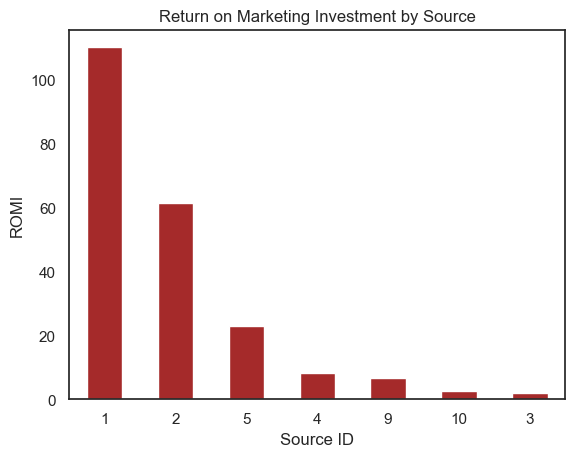

In [44]:
# Agrupación y calculo del ROMI mediante el LTV y CAC
romi_by_source = revenue_by_source.merge(cac_by_source[['source_id','cac_sources']], on='source_id')
romi_by_source['romi_sources'] = romi_by_source['ltv_sources'] / romi_by_source['cac_sources']

# Graficación del ROMI por fuente
romi_by_source.sort_values(by='romi_sources', ascending=False, inplace=True)
romi_by_source.plot(x='source_id', y='romi_sources', kind='bar', title='Return on Marketing Investment by Source',color='brown',rot=0)
plt.legend().remove()
plt.ylabel('ROMI')
plt.xlabel('Source ID')
plt.show()


En este punto es donde podremos comprobar si los inversiones y las ganancias hechas para cada tipo de fuente han valido la pena. Es curioso que para este caso los 3 primero ingresos corresponden a los mismos que en la tabla del LTV, se puede ver que efectivamente son redituables, sin embargo, no todos lo son en la misma medida, la fuente 1 a diferencia de la 2 y 5 de acuerdo con la gráfica muestra que por cada dolar invertido, obtenemos 1.2 dolares de regreso, por lo que el retorno de la inversión es positivo, aunque las ganancias sean pocas. En contraste, para las otras 2 fuentes podemos ver para la fuente 2 por cada dolar, aproximadamente estamos obteniendo $0.6 de ganancia y para la fuente 5 solamente $0.25 por cada dolar invertido, si bien no es algo negativo la recuperación y las ganancias se van a tardar en ver reflejadas. 

Por parte de las fuentes que tienen el ROMI más bajo podemos ver que la fuente número 3 es la que peor retorno de inversión tiene, es demasiado bajo y comparado a lo que se obtiene de inversión de ella y la cantidad de dinero que se le es invertido, no es para nada viable. Para las demás fuentes, 4,9 y 10, tampoco son muy redituables del todo, probablemente no se les haga tanta inversión como la fuente 3, pero tampoco captan mucho capital. Si bien las fuentes con bajas métricas no son negativas, eso no quiere decir que sean redituables para seguir existiendo puesto que sería imposible sostener el negocio si el retorno de la inversión tarda demasiado en devolver el capital.

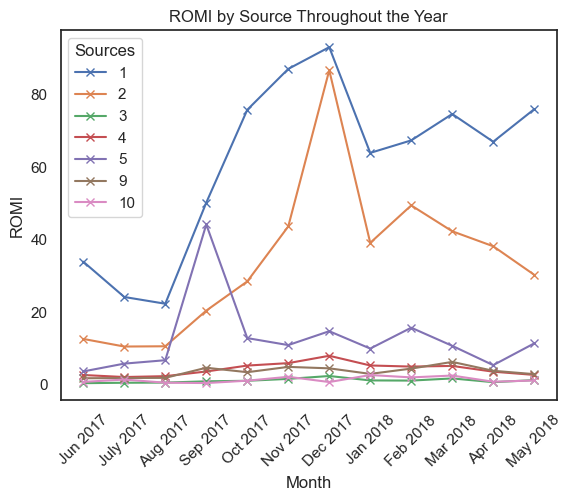

In [45]:
# Agrupación de los datos del LTV y CAC para el cálculo del ROMI
romi_in_time = revenue_by_device.merge(costs_by_source_in_time[['source_id','cac_by_source']], on='source_id', how='outer')
romi_in_time['romi_by_source'] = romi_in_time['ltv_device'] / romi_in_time['cac_by_source']
# Graficación del ROMI a lo largo del año
romi = romi_in_time.pivot_table(index=['session_year','session_month'], columns='source_id', values='romi_by_source').reset_index()
romi.iloc[:,2:].plot(kind='line', title='ROMI by Source Throughout the Year',rot=45, marker='x')
plt.legend(title='Sources')
plt.ylabel('ROMI')
plt.xlabel('Month')
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018'])
plt.show()

Como se vió anteriormente el comportamiento del més de agosto sigue presente para el repunte de los las ganancias, y es claro que la fuente 1 es la que mejor ganancias genera.

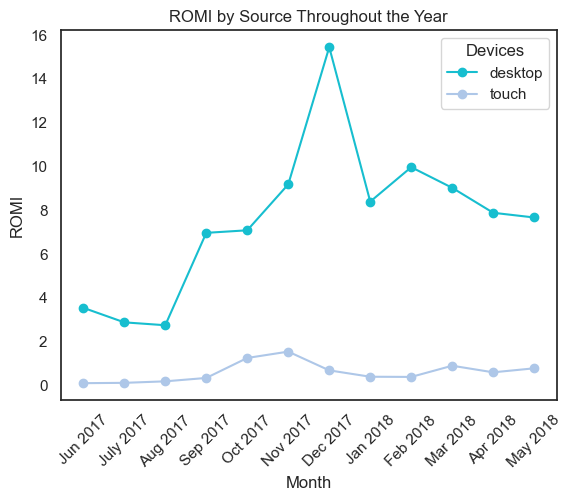

In [46]:
# Agrupación y calculo del ROMI mediante el LTV y CAC por dispositivo
romi_by_device = revenue_by_device.merge(cac_by_devices[['source_id','cac_device']], on='source_id', how='outer')
romi_by_device['romi_device'] = romi_by_device['ltv_device'] / romi_by_device['cac_device']

# Graficación del ROMI a lo largo del año
romi_pivot = romi_by_device.pivot_table(index=['session_year','session_month'], columns='device', values='romi_device').reset_index()
romi_pivot.plot(y=['desktop','touch'], kind='line', title='ROMI by Source Throughout the Year',rot=45, color=['#17BECF','#AEC7E8'], marker='o')
plt.legend(title='Devices')
plt.ylabel('ROMI')
plt.xlabel('Month')
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11], labels=['Jun 2017','July 2017','Aug 2017','Sep 2017','Oct 2017','Nov 2017','Dec 2017','Jan 2018','Feb 2018','Mar 2018','Apr 2018','May 2018'])
plt.show()

Nuevamente se puede ver el dominio de los dispositivos desktop para todo el año. Es sumamente claro que el dispositivo predilecto para los clientes y usuarios son los que están denominados en la categoría de desktop.

# Conlusiones

De acuerdo a lo visto y calculado en las secciones se puede determinar lo siguiente:

* El dispositivo predilecto, de donde se obtiene la mayor cantidad de visitas como de atracción de usuarios y captación de ingresos son de dispositivos de tipo desktop, por lo tanto es que que mayor cantidad CAC, LTV y ROMI. A su vez, es el dispositivo en el que en promedio tardan más en convertirse los usuarios, ya sea por el diseño de las interfaces, problemas técnicos en la plataforma u otros factores que propician que las personas tarden en decidirse hacer una compra. Por otra parte, los dispositivos móviles que son los que menos retorno de inversión tienen así como también los menos populares puede que tengan un mejor desempeño si se comienza a prestar más atención en sus fuentes de marketing y las inversiones, puesto que al principio del proyecto se puede ver que es mediante estos que la conversión de los usuarios dura significativamente menos, además también el promedio de las ganancias es significativamente mayor, esto demuestra que hay un potencial que no ha sido explotado.

* En su gran mayoría es notorio de la gran mayoría de las gráficas que muestran el cambio a travez del tiempo como específicamente el inicio del repunte de muchas de las métricas comienza en el mes de agosto y dura entre 9 a 10 meses la temporada donde tanto las inversiones como las ganancias aumentan. En lo particular sería bueno poner mucho enfasis en ese periodo y verificar si es una constante durante los demás años, para poder estar preparados y generar una mejor estrategia de marketing que ayude a aumentar ganancias y clientes con la menor cantidad de inversión posible considerando que el factor de adherencia es muy bajo y la cantidad de nuevos usuarios es mucha, lo que indica la poca capacidad de retención y por ende el gasto en marketing aumenta para poder evitar que se vayan.

* Acorde con el ROMI calculador para cada guente de marketing el porcentaje en el que debería de invertirse el dinero por fuente debería de ser de la siguiente manera.
  * Source 1 = 51.53% del presupuesto destinado a marketing
  * Source 2 = 28.79% del presupuesto destinado a marketing
  * Source 5 = 10.67% del presupuesto destinado a marketing
  * Source 4 = 3.8% del presupuesto destinado a marketing
  * Source 9 = 3.1% del presupuesto destinado a marketing
  * Source 10 = 1.2% del presupuesto destinado a marketing
  * Source 3 = 1% del presupuesto destinado a marketing

* Para las principales 3 fuentes de marketing que serían las más importantes se destinaría ese porcentaje, aunque para las restantes 4 fuentes de marketing no consideraría viable el seguir invirtiendo porcentajes tan pequeños a esas fuentes que retornan muy poco la inversión. Cabaría la posibilidad de quitar esas fuentes y repartir ese porcentaje del presupuesto a las demás o tratar de mejorar los canales de marketing, aunque personalmente creo que la primera opción sería más viable. 


